# JUNE 25th-anniversary analysis — Step 5: figures and tables

**What this does:** turns the results of Steps 1–4 into figures and tables
for the manuscript. It doesn't download or calculate anything new.

| Question | Figure | Table |
|---|---|---|
| How many items per volume? | `fig1_items_per_volume` | `table1_items_per_volume.csv`, `table1b_item_types_all_volumes.csv` |
| How many FUN workshop issues, and items in each? | `fig2_workshop_items` | `table2_workshops.csv` |
| How have citations changed over time? | `fig3_citations_by_volume` | `table3_citations_by_volume.csv`, `table3b_cumulative_citations.csv` |
| Which items are cited most? | — | `table4_top_cited_total.csv`, `table5_top_cited_5_years.csv` |
| What topics, and how have they changed? | `fig4_topics_by_era` | `table6_topics_by_era.csv`, `table7_keywords_by_era.csv` |

Every figure has a table with the same numbers, so readers (and reviewers)
don't have to read values off a chart.

**What you need to do:** run each cell from top to bottom (a few seconds).
Choices still being discussed (see `OPEN_QUESTIONS.md`) are settings below,
so changing your mind means changing one line and re-running.

**What goes in:** `data/june_matched.csv`, `data/june_citations.csv`,
`data/june_topics.csv`, `data/keyword_counts.csv`, `data/topic_words.csv`

**What comes out:** `figures/` (each figure as PNG for drafts and PDF for
the journal) and `tables/` (CSV files you can paste into the manuscript)

## Running in Google Colab

If you opened this notebook from the "Open in Colab" link, run the next cell
first. It downloads the project's files from GitHub (the CSVs from earlier
steps and `manual_fixes.csv`) so the rest of the notebook can find them.
On your own computer, the cell does nothing.

**Colab forgets everything when the session ends.** To keep a result, download
it from the Files panel (folder icon on the left). Make hand corrections in
`manual_fixes.csv` on GitHub, not in Colab, so they aren't lost.

In [1]:
import os
import subprocess
import sys

if "google.colab" in sys.modules and not os.path.exists("manual_fixes.csv"):
    if not os.path.exists("JUNE_Utilities"):
        subprocess.run(["git", "clone", "https://github.com/ajuavinett/JUNE_Utilities.git"], check=True)
    os.chdir("JUNE_Utilities")
    print("Working in", os.getcwd())

## Settings — the only cell you should normally need to edit

In [2]:
# Open question 3: which item types count in "items per volume"?
# Listed in the order they're stacked in Figure 1 (bottom to top).
COUNT_ITEM_TYPES = ["article", "editorial", "review", "case study", "technical"]

# Open question 4: may workshop articles appear in the top-cited tables?
INCLUDE_WORKSHOP_IN_TOP_CITED = True
# Which item types may appear in the top-cited tables
TOP_CITED_ITEM_TYPES = ["article", "editorial", "review", "case study", "technical"]
TOP_N = 20

# Which item types count in the typical-citations-per-volume figure
CITATION_ITEM_TYPES = ["article", "case study", "technical"]

FIGURES_DIR = "figures"
TABLES_DIR = "tables"

## Setup (no need to edit below this line)

The figure style (Arial, font sizes, and the color-blind-safe Okabe–Ito
colors) lives in `june.mplstyle`, shared by every notebook. Item types always
get the same color, in a fixed order, in every figure.

In [3]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

matched = pd.read_csv("data/june_matched.csv", keep_default_na=False, encoding="utf-8-sig")
citations = pd.read_csv("data/june_citations.csv", keep_default_na=False, encoding="utf-8-sig")
topics = pd.read_csv("data/june_topics.csv", keep_default_na=False, encoding="utf-8-sig")
topic_words = pd.read_csv("data/topic_words.csv", keep_default_na=False, encoding="utf-8-sig")
keywords = pd.read_csv("data/keyword_counts.csv", keep_default_na=False, encoding="utf-8-sig")
for df in (matched, citations, topics):
    df["is_fun_workshop"] = df["is_fun_workshop"].astype(str) == "True"

# Shared figure style (Arial, Okabe–Ito colors, font sizes): see june.mplstyle
plt.style.use("june.mplstyle")
BLUE, ORANGE, GREEN, PINK, SKY = "#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9"
TYPE_COLORS = {"article": BLUE, "editorial": ORANGE, "review": GREEN, "case study": PINK, "technical": SKY}
TEXT, TEXT_2, SURFACE = "#0b0b0b", "#404040", "#ffffff"
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#f4f8fe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])


def save(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIGURES_DIR, f"{name}.{ext}"))
    print(f"saved {FIGURES_DIR}/{name}.png and .pdf")


def save_table(df, name, index=False):
    df.to_csv(os.path.join(TABLES_DIR, f"{name}.csv"), index=index, encoding="utf-8-sig")
    print(f"saved {TABLES_DIR}/{name}.csv")

## Figure 1: items per volume

FUN workshop items are **included**, each counted under its own item type
(decided 2026-10-04); the table also lists how many of each volume's items
are workshop items. Workshop totals are in Figure 2. Volumes span two
calendar years; the table lists both.

saved tables/table1_items_per_volume.csv


saved figures/fig1_items_per_volume.png and .pdf
saved tables/table1b_item_types_all_volumes.csv


item_type,years,article,editorial,review,case study,technical,total,of which FUN workshop items
volume,,,,,,,,
1,2002–2003,8,3,7,0,0,18,0
2,2003–2004,9,3,5,0,0,17,0
3,2004–2005,11,3,2,0,0,16,0
4,2005–2006,11,6,2,0,0,19,0
5,2006–2007,11,8,5,0,0,24,0
6,2007–2008,12,4,2,0,0,18,0
7,2008–2009,12,4,1,0,0,17,0
8,2009–2010,26,2,0,0,0,28,19
9,2010–2011,15,5,0,0,0,20,0


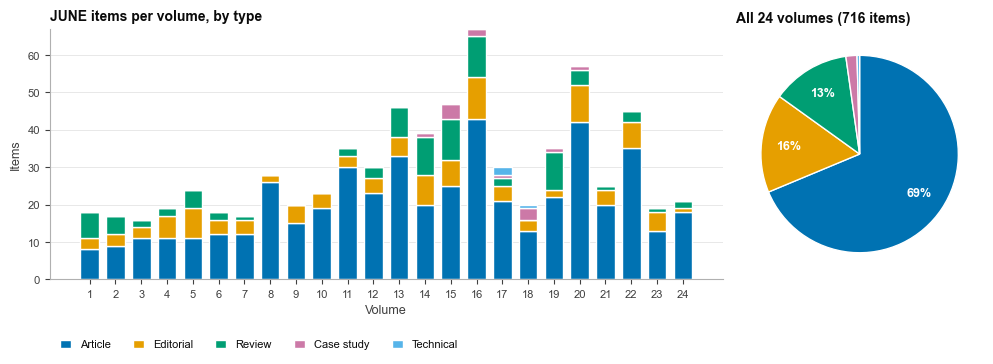

In [4]:
# FUN workshop items are included, each counted under its own item type
counted = matched[matched["item_type"].isin(COUNT_ITEM_TYPES)]
per_volume = (counted.groupby(["volume", "item_type"]).size().unstack(fill_value=0)
              .reindex(columns=COUNT_ITEM_TYPES, fill_value=0))
years = matched.groupby("volume")["year_label"].agg(["min", "max"])
table1 = per_volume.copy()
table1.insert(0, "years", [f"{years.at[v, 'min']}–{years.at[v, "max"]}" for v in table1.index])
table1["total"] = per_volume.sum(axis=1)
table1["of which FUN workshop items"] = (counted[counted["is_fun_workshop"]].groupby("volume").size()
                                               .reindex(table1.index, fill_value=0))
save_table(table1, "table1_items_per_volume", index=True)

# Left: items per volume (stacked bars). Right: all volumes together (pie).
fig, (ax, pie_ax) = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={"width_ratios": [3, 1.1]})
bottom = pd.Series(0, index=per_volume.index)
for t in COUNT_ITEM_TYPES:
    ax.bar(per_volume.index, per_volume[t], bottom=bottom, width=0.72, color=TYPE_COLORS[t],
           edgecolor=SURFACE, linewidth=1, label=t.capitalize())
    bottom += per_volume[t]
ax.margins(y=0.08)
ax.set_xticks(per_volume.index)
ax.set_xlabel("Volume")
ax.set_ylabel("Items")
ax.set_title("JUNE items per volume, by type")
ax.legend(ncols=len(COUNT_ITEM_TYPES), loc="upper left", bbox_to_anchor=(0, -0.2), handlelength=1)
ax.grid(axis="x", visible=False)

# Pie: the same items, all volumes together. Slices go clockwise from the top in
# the same order (and colors) as the bars. Only slices of 5% or more are labeled
# on the chart; the legend and table1b carry the rest.
totals = per_volume.sum()
shares = 100 * totals / totals.sum()
pie_ax.pie(totals, colors=[TYPE_COLORS[t] for t in totals.index], startangle=90, counterclock=False,
           wedgeprops={"edgecolor": SURFACE, "linewidth": 1},
           autopct=lambda pct: f"{pct:.0f}%" if pct >= 5 else "", pctdistance=0.72,
           textprops={"color": SURFACE, "fontsize": 9, "fontweight": "bold"})
pie_ax.set_title(f"All {per_volume.index.nunique()} volumes ({totals.sum()} items)")
pie_ax.set_aspect("equal")
fig.tight_layout()
save(fig, "fig1_items_per_volume")

table1b = pd.DataFrame({"items": totals, "% of all items": shares.round(1)})
table1b.index.name = "item type"
save_table(table1b, "table1b_item_types_all_volumes", index=True)
table1

## Figure 2: FUN workshop issues

saved tables/table2_workshops.csv


saved figures/fig2_workshop_items.png and .pdf


,volume,issue,issue year,workshop_name,items,articles
0,8,1,2009,FUN 2008 Macalester workshop,19,19
1,11,1,2012,FUN 2011 Pomona workshop,29,27
2,13,3,2015,FUN 2014 Ithaca workshop,20,18
3,16,3,2018,FUN 2017 workshop,21,17
4,20,2,2022,FUN 2020 Summer Virtual Meeting,28,23
5,22,2,2024,FUN 2023 Western Washington workshop,16,11


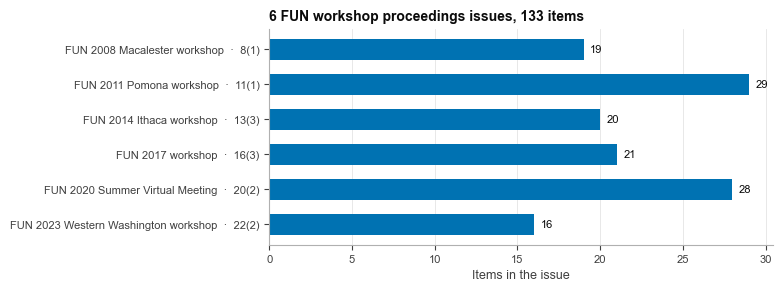

In [5]:
workshop = matched[matched["is_fun_workshop"]]
table2 = (workshop.groupby(["volume", "issue", "year_label", "workshop_name"])
          .agg(items=("item_id", "size"), articles=("item_type", lambda s: (s == "article").sum()))
          .reset_index().rename(columns={"year_label": "issue year"}))
save_table(table2, "table2_workshops")

fig, ax = plt.subplots(figsize=(6.5, 2.8))
labels = [f"{r.workshop_name}  ·  {r.volume}({r.issue})" for r in table2.itertuples()]
ax.barh(labels, table2["items"], height=0.6, color=BLUE)
for y, n in enumerate(table2["items"]):
    ax.text(n + 0.4, y, str(n), va="center", color=TEXT, fontsize=8)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlabel("Items in the issue")
ax.set_title(f"{len(table2)} FUN workshop proceedings issues, {table2['items'].sum()} items")
save(fig, "fig2_workshop_items")
table2

## Figure 3: citations by volume

The **median** (typical) article's citations in each volume. Older articles
have had more time to be cited, so the total count naturally falls for
recent volumes; the first-5-years count is the fairer comparison over time.
Volumes too recent for a complete 5-year window are left out of that panel.

saved tables/table3_citations_by_volume.csv
saved tables/table3b_cumulative_citations.csv


saved figures/fig3_citations_by_volume.png and .pdf


,citations that year,cumulative citations
year,,
2003,2,2
2004,4,6
2005,12,18
2006,21,39
2007,48,87
2008,22,109
2009,54,163
2010,34,197
2011,60,257


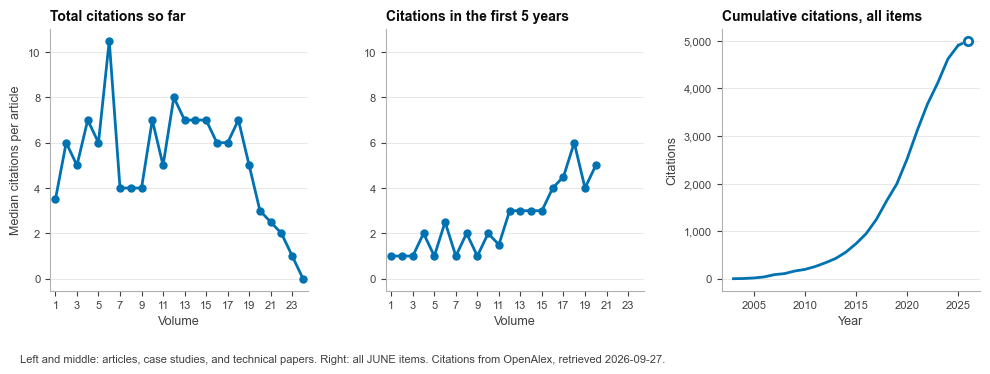

In [6]:
cit = citations[citations["item_type"].isin(CITATION_ITEM_TYPES)].copy()
for col in ["citations_total", "citations_first_5_years"]:
    cit[col] = pd.to_numeric(cit[col], errors="coerce")
table3 = cit.groupby("volume").agg(
    articles=("item_id", "size"),
    median_total=("citations_total", "median"),
    median_first_5_years=("citations_first_5_years", "median"),
    articles_with_5_year_window=("citations_first_5_years", "count"),
)
save_table(table3, "table3_citations_by_volume", index=True)

# Cumulative citations to all JUNE items, by the year the citing paper came out
# (built from each item's "citations_by_year", e.g. "2011: 2; 2012: 5").
# OpenAlex dates a few citing papers (~1.5%) before the item they cite — some a
# year early (online before print), some clearly wrong (e.g., 1959). Those are
# counted in the cited item's publication year instead.
per_year = {}
for text, published in zip(citations["citations_by_year"], citations["year_label"].astype(int)):
    for part in filter(None, str(text).split(";")):
        year, n = part.split(":")
        year = max(int(year), published)
        per_year[year] = per_year.get(year, 0) + int(n)
retrieved = citations["citations_retrieved"].iloc[0]
this_year = int(retrieved[:4])
table3b = pd.DataFrame({"citations that year": pd.Series(per_year).sort_index()})
table3b = table3b[table3b.index <= this_year]
table3b["cumulative citations"] = table3b["citations that year"].cumsum()
table3b.index.name = "year"
save_table(table3b, "table3b_cumulative_citations", index=True)

# Left two panels share a scale (median per article); the right panel has its own
fig = plt.figure(figsize=(12, 3.4))
grid = fig.add_gridspec(1, 3, wspace=0.3)
axes = [fig.add_subplot(grid[0])]
axes.append(fig.add_subplot(grid[1], sharey=axes[0]))
cum_ax = fig.add_subplot(grid[2])
panels = [("median_total", "Total citations so far"),
          ("median_first_5_years", "Citations in the first 5 years")]
for ax, (col, title) in zip(axes, panels):
    s = table3[col].dropna()
    ax.plot(s.index, s.values, color=BLUE, linewidth=2, marker="o", markersize=5)
    ax.set_title(title)
    ax.set_xlabel("Volume")
    ax.set_xticks(range(1, int(table3.index.max()) + 1, 2))
    ax.set_xlim(0.5, table3.index.max() + 0.5)
axes[0].set_ylabel("Median citations per article")
complete = table3b[table3b.index < this_year]["cumulative citations"]
cum_ax.plot(complete.index, complete.values, color=BLUE, linewidth=2)
cum_ax.plot([complete.index[-1], this_year], [complete.iloc[-1], table3b.at[this_year, "cumulative citations"]],
            color=BLUE, linewidth=2, linestyle=(0, (2, 2)))
cum_ax.plot(this_year, table3b.at[this_year, "cumulative citations"], marker="o", markersize=6,
            markerfacecolor=SURFACE, markeredgecolor=BLUE, markeredgewidth=2)
cum_ax.set_title("Cumulative citations, all items")
cum_ax.set_xlabel("Year")
cum_ax.set_ylabel("Citations")
cum_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
fig.text(0.1, -0.1, f"Left and middle: articles, case studies, and technical papers. Right: all JUNE items. "
         f"Citations from OpenAlex, retrieved {retrieved}.", color=TEXT_2, fontsize=8)
save(fig, "fig3_citations_by_volume")
table3b

## Tables 4 and 5: most-cited items

In [7]:
top = citations[citations["item_type"].isin(TOP_CITED_ITEM_TYPES)].copy()
if not INCLUDE_WORKSHOP_IN_TOP_CITED:
    top = top[~top["is_fun_workshop"]]
for col in ["citations_total", "citations_first_5_years", "icite_citations"]:
    top[col] = pd.to_numeric(top[col], errors="coerce").astype("Int64")
top["volume(issue)"] = top["volume"].astype(str) + "(" + top["issue"].astype(str) + ")"
top["FUN workshop"] = top["is_fun_workshop"].map({True: "yes", False: ""})
top["url"] = top["item_id"].map(matched.set_index("item_id")["url"])   # link to each article
cols = ["title", "first_author", "year_label", "volume(issue)", "item_type", "FUN workshop",
        "citations_total", "citations_first_5_years", "url"]
table4 = top.sort_values("citations_total", ascending=False)[cols].head(TOP_N)
table5 = top.dropna(subset=["citations_first_5_years"]).sort_values(
    "citations_first_5_years", ascending=False)[cols].head(TOP_N)
for t in (table4, table5):
    t.insert(0, "rank", range(1, len(t) + 1))
save_table(table4, "table4_top_cited_total")
save_table(table5, "table5_top_cited_5_years")
table4

saved tables/table4_top_cited_total.csv
saved tables/table5_top_cited_5_years.csv


,rank,title,first_author,year_label,volume(issue),item_type,FUN workshop,citations_total,citations_first_5_years,url
235,1,Opinion: Science Communication to the General ...,Brownell,2013,12(1),editorial,,414,52,https://www.funjournal.org/wp-content/uploads/...
295,2,Retention of Underrepresented Minority Faculty...,Joseph,2015,13(3),article,yes,157,35,https://www.funjournal.org/wp-content/uploads/...
86,3,Methods for Handling Missing Data in the Behav...,Rubin,2007,5(2),article,,131,3,https://www.funjournal.org/wp-content/uploads/...
212,4,Classroom Activities: Simple Strategies to Inc...,Lom,2012,11(1),article,yes,106,31,https://www.funjournal.org/wp-content/uploads/...
209,5,Cultivating Diversity and Competency in STEM: ...,Whittaker,2012,11(1),article,yes,72,13,https://www.funjournal.org/wp-content/uploads/...
431,6,Using ImageJ to Assess Neurite Outgrowth in Ma...,Pemberton,2018,16(2),article,,60,34,https://www.funjournal.org/wp-content/uploads/...
571,7,Why Students Cheat and How Understanding This ...,Miles,2022,20(2),article,yes,56,<NA>,https://doi.org/10.59390/LXMJ2920
29,8,Measuring Salivary Cortisol in the Behavioral ...,Kalman,2004,2(2),article,,53,5,https://www.funjournal.org/wp-content/uploads/...
171,9,Undergraduate Neuroscience Education in the U....,Ramos,2011,9(2),article,,50,11,https://www.funjournal.org/wp-content/uploads/...
456,10,A Discussion of Diversity and Inclusivity at t...,Martinez,2018,16(3),article,yes,47,26,https://www.funjournal.org/wp-content/uploads/...


In [8]:
table5

,rank,title,first_author,year_label,volume(issue),item_type,FUN workshop,citations_total,citations_first_5_years,url
235,1,Opinion: Science Communication to the General ...,Brownell,2013,12(1),editorial,,414,52,https://www.funjournal.org/wp-content/uploads/...
295,2,Retention of Underrepresented Minority Faculty...,Joseph,2015,13(3),article,yes,157,35,https://www.funjournal.org/wp-content/uploads/...
431,3,Using ImageJ to Assess Neurite Outgrowth in Ma...,Pemberton,2018,16(2),article,,60,34,https://www.funjournal.org/wp-content/uploads/...
212,4,Classroom Activities: Simple Strategies to Inc...,Lom,2012,11(1),article,yes,106,31,https://www.funjournal.org/wp-content/uploads/...
455,5,The New Blueprints: Undergraduate Neuroscience...,Wiertelak,2018,16(3),article,yes,37,26,https://www.funjournal.org/wp-content/uploads/...
456,6,A Discussion of Diversity and Inclusivity at t...,Martinez,2018,16(3),article,yes,47,26,https://www.funjournal.org/wp-content/uploads/...
519,7,Integrating Research into the Undergraduate Cu...,Morrison,2020,19(1),article,,26,21,https://www.funjournal.org/wp-content/uploads/...
518,8,Integrating Research into the Undergraduate Cu...,Buffalari,2020,19(1),article,,22,20,https://www.funjournal.org/wp-content/uploads/...
257,9,Complementing Neurophysiology Education for De...,Diwakar,2014,12(2),article,,35,20,https://www.funjournal.org/wp-content/uploads/...
366,10,“Social” Neuroscience: Leveraging Social Media...,Valentine,2016,15(1),article,,22,20,https://www.funjournal.org/wp-content/uploads/...


## Figure 4: topics by era

Each cell is the percentage of that era's articles whose main topic is that
topic (each column adds up to 100%). Darker = more common. Topics are
listed from most to least common overall. Topic names come from
`TOPIC_NAMES` in Step 4.

saved tables/table6_topics_by_era.csv


saved figures/fig4_topics_by_era.png and .pdf


era,top words,Vol 1–5 (2002–2007),Vol 6–10 (2007–2012),Vol 11–15 (2012–2017),Vol 16–20 (2017–2022),Vol 21–24 (2022–2026),all eras
main_topic_name,,,,,,,
Topic 10,"science, interdisciplinary, curriculum, knowle...",12.0,14.3,17.6,11.8,16.3,14.6
Topic 1,"laboratory, data, behavioral, animal, experime...",28.0,22.6,6.6,11.2,8.1,13.0
Topic 12,"active, lecture, game, activity, large, thinki...",2.0,2.4,8.8,7.9,15.1,7.9
Topic 13,"neural, computational, network, simulations, s...",10.0,7.1,7.4,6.6,10.5,7.9
Topic 11,"graduate, diversity, training, institutions, a...",8.0,8.3,4.4,9.2,8.1,7.5
Topic 7,"outreach, school, community, service, high sch...",2.0,6.0,8.1,6.6,5.8,6.3
Topic 5,"online, lab, video, in-person, virtual, instru...",6.0,3.6,2.9,10.5,4.7,5.9
Topic 14,"drosophila, behavior, optogenetics, neurons, b...",4.0,4.8,7.4,5.3,5.8,5.7
Topic 3,"brain, allen, data, allen brain, neuroanatomy,...",0.0,3.6,2.9,9.9,7.0,5.5


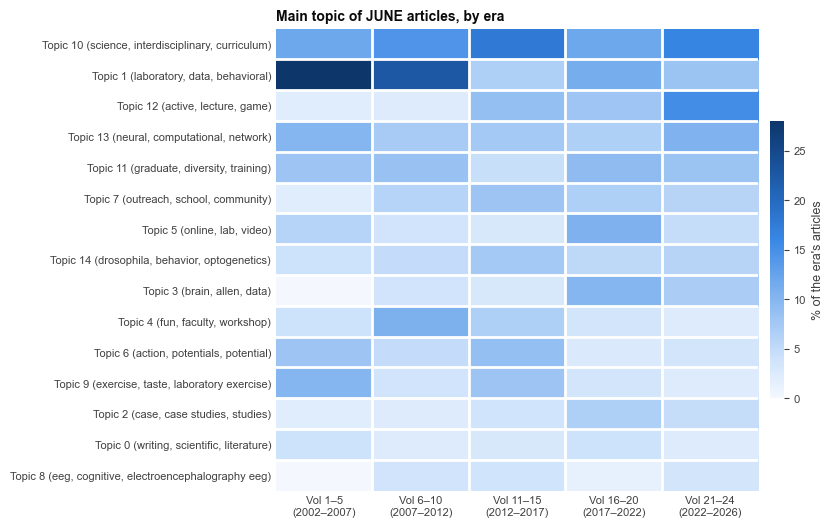

In [9]:
era_order = list(dict.fromkeys(topics.sort_values("volume")["era"]))
share = (pd.crosstab(topics["main_topic_name"], topics["era"], normalize="columns")
         .mul(100).reindex(columns=era_order))
share["all eras"] = topics["main_topic_name"].value_counts(normalize=True).mul(100)
share = share.sort_values("all eras", ascending=False)
words = dict(zip(topic_words["name"], topic_words["top words"]))
table6 = share.round(1)
table6.insert(0, "top words", [words.get(n, "") for n in table6.index])
save_table(table6, "table6_topics_by_era", index=True)

fig, ax = plt.subplots(figsize=(7.5, 6))
data = share[era_order]
im = ax.imshow(data.values, cmap=BLUES, aspect="auto", vmin=0)
ax.set_xticks(range(len(era_order)), [e.replace(" (", "\n(") for e in era_order])
short = [f"{n} ({', '.join(words.get(n, '').split(', ')[:3])})" if n.startswith("Topic") else n
         for n in data.index]
ax.set_yticks(range(len(data)), short)
ax.tick_params(length=0)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([x - 0.5 for x in range(1, len(era_order))], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, len(data))], minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="minor", length=0)
bar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
bar.set_label("% of the era's articles", color=TEXT_2)
bar.outline.set_visible(False)
ax.set_title("Main topic of JUNE articles, by era")
save(fig, "fig4_topics_by_era")
table6

## Table 7: most-used keywords, by era

In [10]:
table7 = keywords.head(25)
save_table(table7, "table7_keywords_by_era")
table7

saved tables/table7_keywords_by_era.csv


,keyword,articles,"% of articles, Vol 1–5 (2002–2007)","% of articles, Vol 6–10 (2007–2012)","% of articles, Vol 11–15 (2012–2017)","% of articles, Vol 16–20 (2017–2022)","% of articles, Vol 21–24 (2022–2026)"
0,active learning,33,0.0,0.0,6.6,10.5,9.3
1,neuroanatomy,21,4.0,6.0,1.5,5.3,4.7
2,electrophysiology,21,2.0,0.0,6.6,5.3,3.5
3,case study,18,2.0,0.0,3.7,5.9,3.5
4,action potential,17,4.0,4.8,2.9,2.6,3.5
5,neurophysiology,15,4.0,2.4,2.9,2.6,3.5
6,outreach,14,0.0,1.2,2.9,2.6,5.8
7,cure,14,0.0,0.0,0.0,5.3,7.0
8,assessment,13,0.0,1.2,2.9,3.9,2.3
9,service learning,12,2.0,2.4,2.2,3.3,1.2
